# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer** - **There were a total of 17 campaigns that occurred between May 2008 and November 2010**

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from random import shuffle, seed

In [313]:
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')

In [314]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



## **3.0 Data Checks and Cleansing**

**3.1 Identify and list the Numerical and Categorical Columns**


In [315]:
# Data types
print(df.dtypes)


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [316]:
# Find numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Find categorical (object or category) columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)


Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [317]:
# Quick stats
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**3.2 Data checks**

In [318]:
# Summary statistics for numeric columns
print("\nSummary stats for numeric columns:")
print(df[num_cols].describe().T)

# --- Categorical columns ---
cat_cols = df.select_dtypes(include=["object", "category"]).columns
print("\nCategorical columns:", list(cat_cols))

# For each categorical column, show unique values and counts
for col in cat_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())
    print("Value counts:")
    print(df[col].value_counts(normalize=True).round(3))
# Duplicates
print("Duplicates:", df.duplicated().sum())


Summary stats for numeric columns:
                  count         mean         std       min       25%  \
age             41188.0    40.024060   10.421250    17.000    32.000   
duration        41188.0   258.285010  259.279249     0.000   102.000   
campaign        41188.0     2.567593    2.770014     1.000     1.000   
pdays           41188.0   962.475454  186.910907     0.000   999.000   
previous        41188.0     0.172963    0.494901     0.000     0.000   
emp.var.rate    41188.0     0.081886    1.570960    -3.400    -1.800   
cons.price.idx  41188.0    93.575664    0.578840    92.201    93.075   
cons.conf.idx   41188.0   -40.502600    4.628198   -50.800   -42.700   
euribor3m       41188.0     3.621291    1.734447     0.634     1.344   
nr.employed     41188.0  5167.035911   72.251528  4963.600  5099.100   

                     50%       75%       max  
age               38.000    47.000    98.000  
duration         180.000   319.000  4918.000  
campaign           2.000     3

***Observation:***

**Numeric Features**




*   *Age*: Average age is ~40 years, with most clients between 32 and 47 years old. The youngest client is 17, and the oldest is 98 → broad age distribution.

*   *Duration*: Average call duration is ~258 seconds, but values range from 0 to nearly 4,900 seconds, showing **strong skewness** and **outliers**.

*   *Campaign*: Average of ~2.6 contacts per campaign. Median is 2 contacts per campaign, but the max is 56 → some customers were contacted excessively.

*   *Pdays*: Almost always 999 (meaning “not previously contacted”), so this variable is highly **imbalanced** and may need special handling.

*   *Previous*: Most values are 0 with a few up to 7, meaning few customers were contacted in prior campaigns.

**Categorical Features**

*   *Job*: 12 categories. The most common are admin. (25%), blue-collar (22%), and technician (16%). Rare categories include student (2%) and unemployed (2.5%). About 1% are unknown.

*   Marital: Majority are married (61%), followed by single (28%). Only ~0.2% are unknown.

*   Education: Most customers have university degrees (30%) or high school (23%). Very few are illiterate. About 4% are unknown.

*   Default: Almost all are reported as no (79%). About 21% are unknown, and yes is almost nonexistent.

*   Housing loans: More than half (52%) have a housing loan, 45% do not, 2% unknown.

*   Personal loans: Majority do not have a personal loan (82%), 15% do, 2% unknown.

*   Contact type: 64% were contacted by cellular, 36% by telephone.

*   Month: Most contacts were made in May (33%), followed by July (17%) and August (15%). Very few in December (~0.4%). → suggests seasonal bias in campaigns.

*   Day of week: Fairly balanced across weekdays, each ~19–21%.

*   Poutcome (previous campaign outcome): Mostly nonexistent (86%), with 10% failure and 3% success.

*   Target (y): Only ~11% said yes to subscribing → strong class imbalance.

**Key Takeaways**

*   Imbalance: Target variable is highly imbalanced (89% “no”, 11% “yes”), which needs balancing (SMOTE or class weights).

*   High skew/outliers: Variables like duration and campaign are skewed with extreme values.

*   Special values: pdays is dominated by 999 → must be recoded into a flag + clean variable.

*   Categorical dominance: Certain categories dominate (e.g., May for month, admin./blue-collar for job), which may bias models if not handled.

In [319]:
# Missing values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [320]:
# 1) CLEAN CATEGORICAL COLUMNS
#    pdays, default, job, education, loan, housing
# ------------------------------------------------------------

# (a)  Drop `pdays`
#df= df.drop(columns=['pdays'])

# (b) default: extremely imbalanced ("no" or "unknown"), often not useful -> drop
if "default" in df.columns:
    df = df.drop(columns=["default"])

# (c) Replace 'unknown' in selected categorical columns with a friendlier 'Other'
for col in ["job", "education", "loan", "housing"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"unknown": "Other"})
        df[col] = df[col].astype("category")
#Quick check

print(df[["job", "education", "loan", "housing"]].value_counts())


job          education            loan   housing
admin.       university.degree    no     yes        2547
                                         no         2146
blue-collar  basic.9y             no     yes        1580
technician   professional.course  no     yes        1516
blue-collar  basic.9y             no     no         1429
                                                    ... 
Other        high.school          yes    no            1
             professional.course  yes    no            1
                                         yes           1
unemployed   basic.6y             Other  Other         1
             Other                yes    yes           1
Name: count, Length: 420, dtype: int64


Handle Outliers


In [321]:
# 2) HANDLE OUTLIERS (NUMERIC) -  duration, campaign, previous, age
#    CAP extreme values using the IQR rule.
# ------------------------------------------------------------

def cap_outliers_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    """
    Caps values outside [Q1 - k*IQR, Q3 + k*IQR] to the boundary.
    """
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return s.clip(lower=lower, upper=upper)

# NOTE on 'duration':# This feature is only known AFTER the call ends and leaks target information.
# For a realistic predictive model, you should DROP it.
# Drop duration
if "duration" in df.columns:
    df = df.drop(columns=["duration"])


# Cap outliers for campaign, previous, age (keep these in the model)
for col in ["campaign", "previous", "age"]:
    if col in df.columns:
        # Work on numeric only
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = cap_outliers_iqr(df[col])
        df[col] = df[col].astype(int)


# 3) QUICK CHECKS
# ------------------------------------------------------------
print("Cleaned columns ready. Preview:")
cols_show = [c for c in ["pdays","pdays_clean","previous_contact","job","education","loan","housing","campaign","previous","age"] if c in df.columns]
print(df[cols_show].head())




Cleaned columns ready. Preview:
   pdays        job    education loan housing  campaign  previous  age
0    999  housemaid     basic.4y   no      no         1         0   56
1    999   services  high.school   no      no         1         0   57
2    999   services  high.school   no     yes         1         0   37
3    999     admin.     basic.6y   no      no         1         0   40
4    999   services  high.school  yes      no         1         0   56


In [322]:

# Remove rows where loan == "Other"
df = df[df["loan"] != "Other"]

# Quick check
print(df["loan"].value_counts())

loan
no       33950
yes       6248
Other        0
Name: count, dtype: int64


In [323]:
df.marital.value_counts()

,count
marital,
married,24340
single,11288
divorced,4491
unknown,79


In [324]:
# Replace 'unknown' with the most common category 'married'
df["marital"] = df["marital"].replace("unknown", "married")

# Check updated counts
print(df["marital"].value_counts())


marital
married     24419
single      11288
divorced     4491
Name: count, dtype: int64


In [325]:
print(df["previous"].value_counts())
#need to drop Previous

previous
0    40198
Name: count, dtype: int64


In [326]:
df = df.drop(columns=["previous"])

## **EDA:**

# Summary statistics for numeric columns

In [327]:
print(df.describe().T)

                  count         mean         std       min       25%  \
age             40198.0    39.934997   10.111884    17.000    32.000   
campaign        40198.0     2.275685    1.551328     1.000     1.000   
pdays           40198.0   962.415817  187.057645     0.000   999.000   
emp.var.rate    40198.0     0.081109    1.570546    -3.400    -1.800   
cons.price.idx  40198.0    93.574178    0.578194    92.201    93.075   
cons.conf.idx   40198.0   -40.507856    4.629656   -50.800   -42.700   
euribor3m       40198.0     3.620509    1.734312     0.634     1.344   
nr.employed     40198.0  5167.050162   72.228813  4963.600  5099.100   

                     50%       75%       max  
age               38.000    47.000    69.000  
campaign           2.000     3.000     6.000  
pdays            999.000   999.000   999.000  
emp.var.rate       1.100     1.400     1.400  
cons.price.idx    93.749    93.994    94.767  
cons.conf.idx    -41.800   -36.400   -26.900  
euribor3m          4.8

## **1. Univariate Analysis**

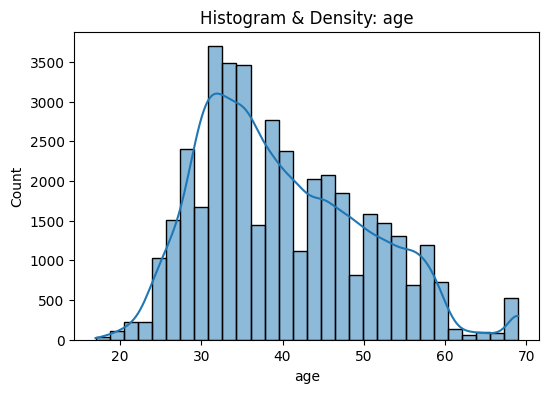

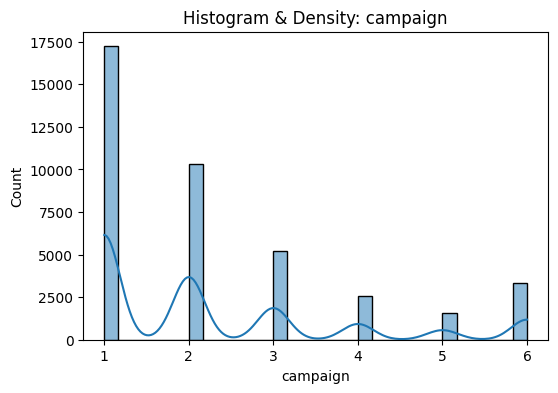

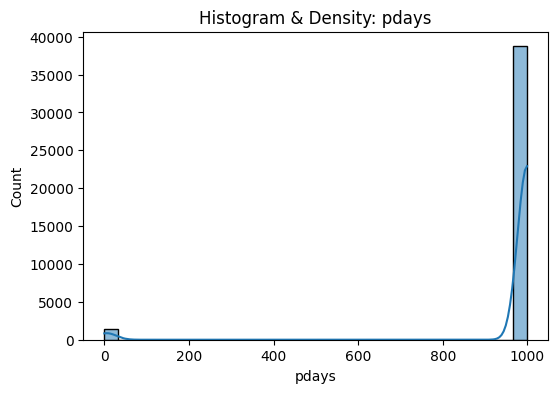

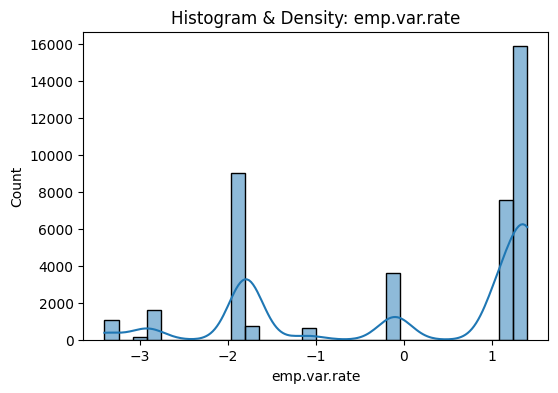

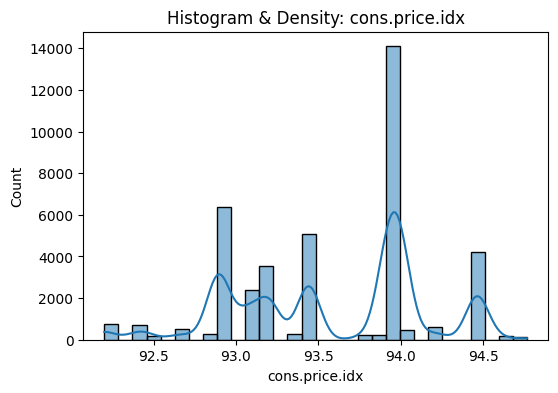

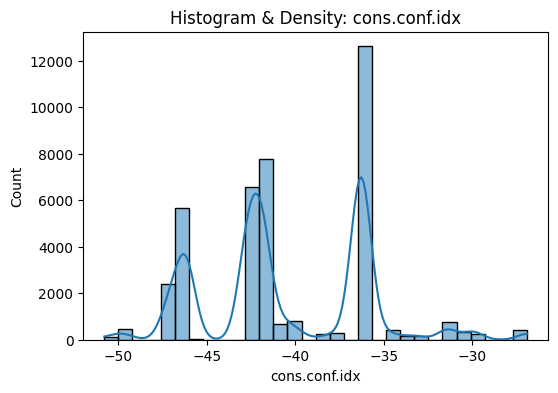

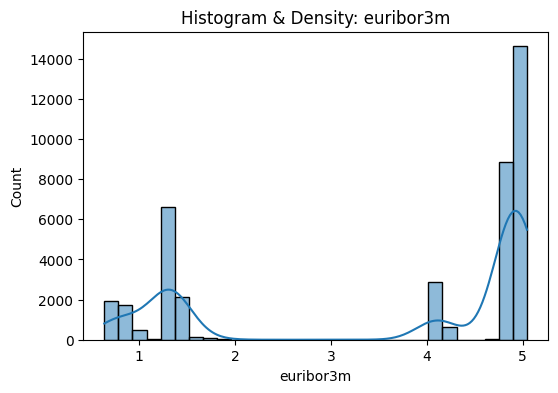

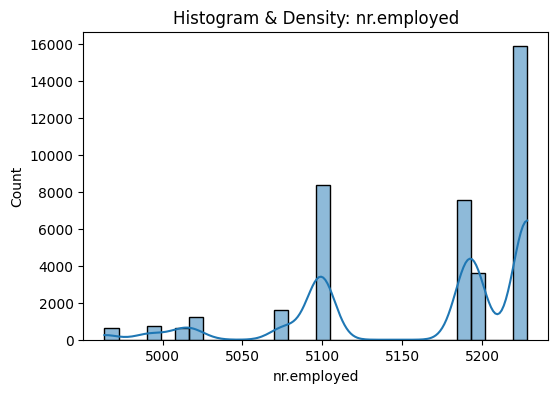

In [328]:
# Histograms + Density plots
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"Histogram & Density: {col}")
    plt.show()

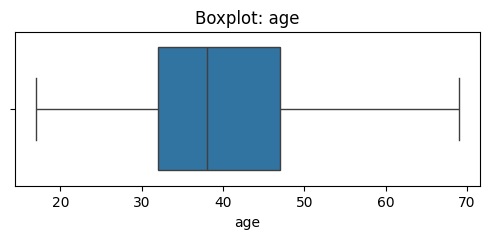

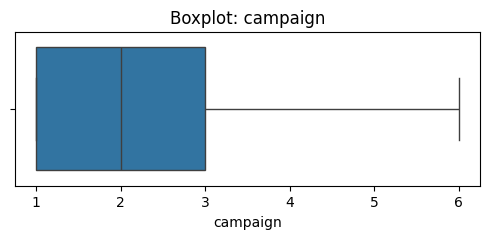

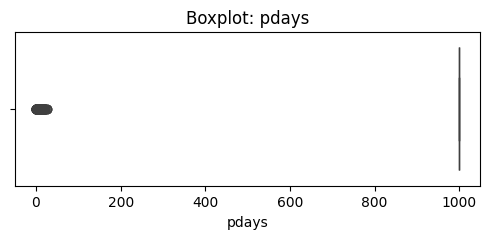

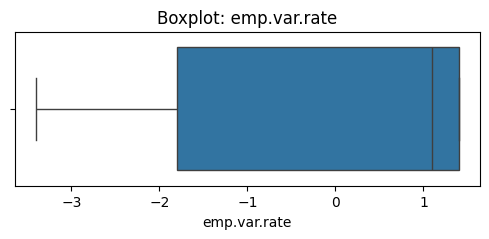

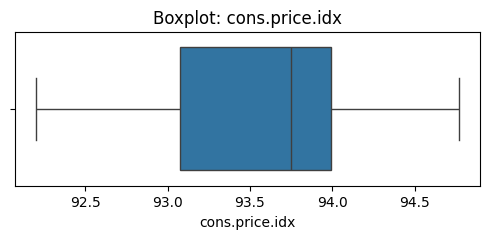

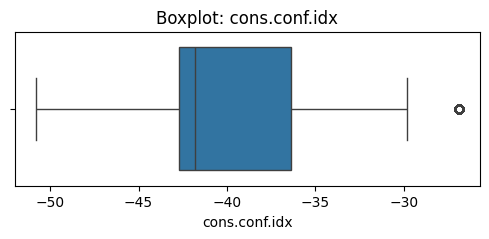

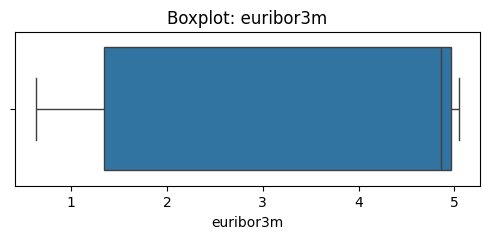

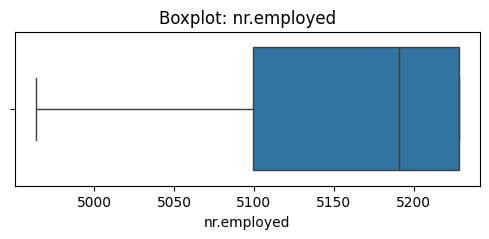

In [329]:
# Boxplots for numeric features
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

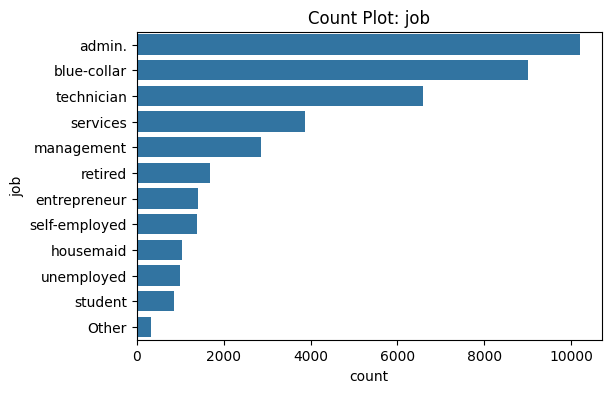

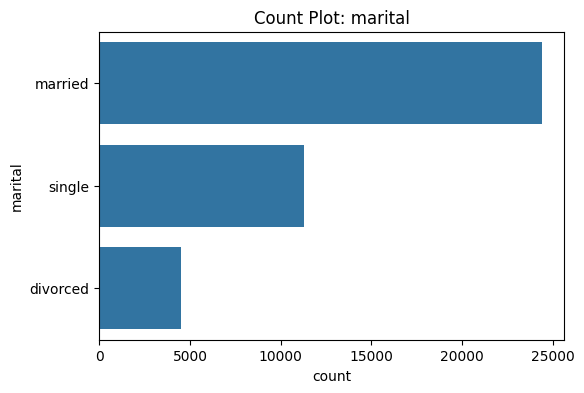

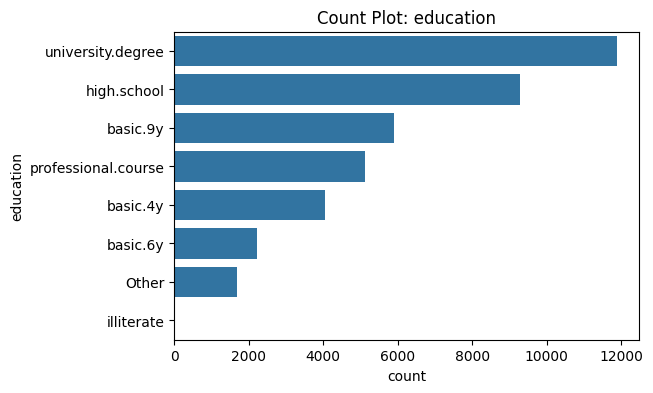

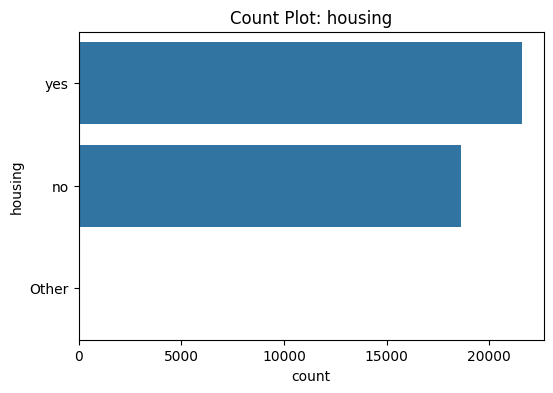

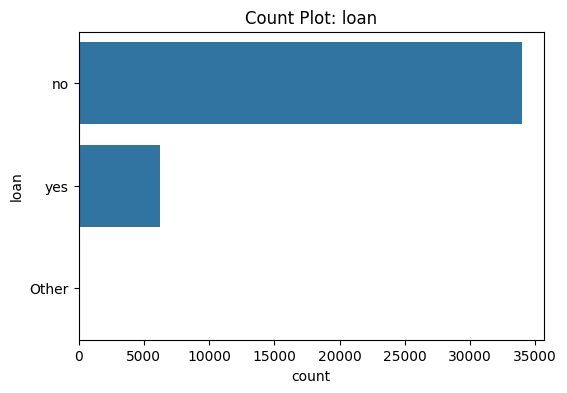

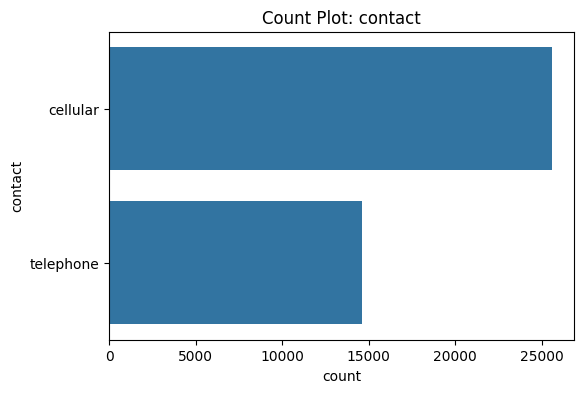

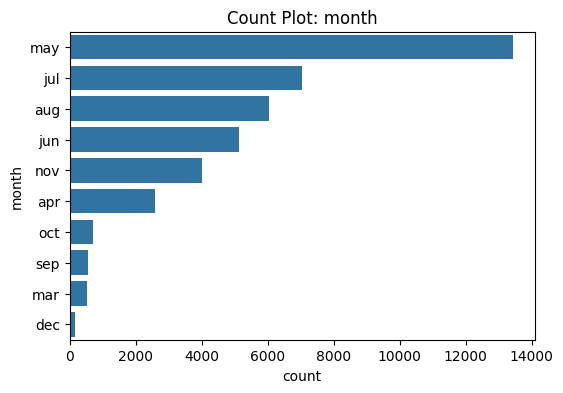

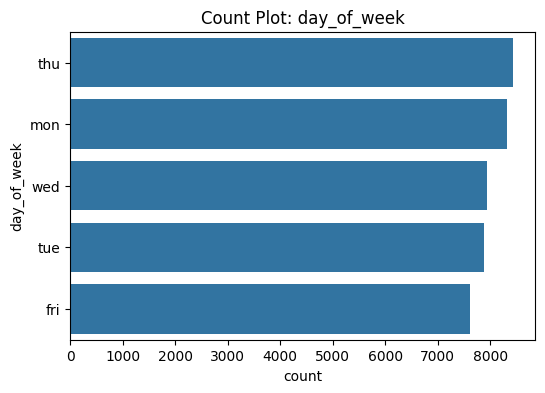

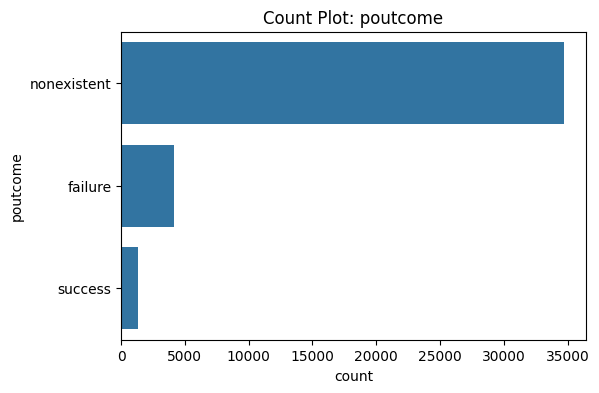

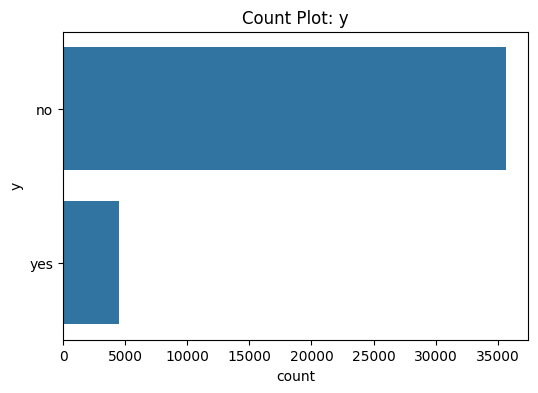

In [330]:
# Count plots for categorical variables
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Count Plot: {col}")
    plt.show()

## **2. Bivariate Analysis**

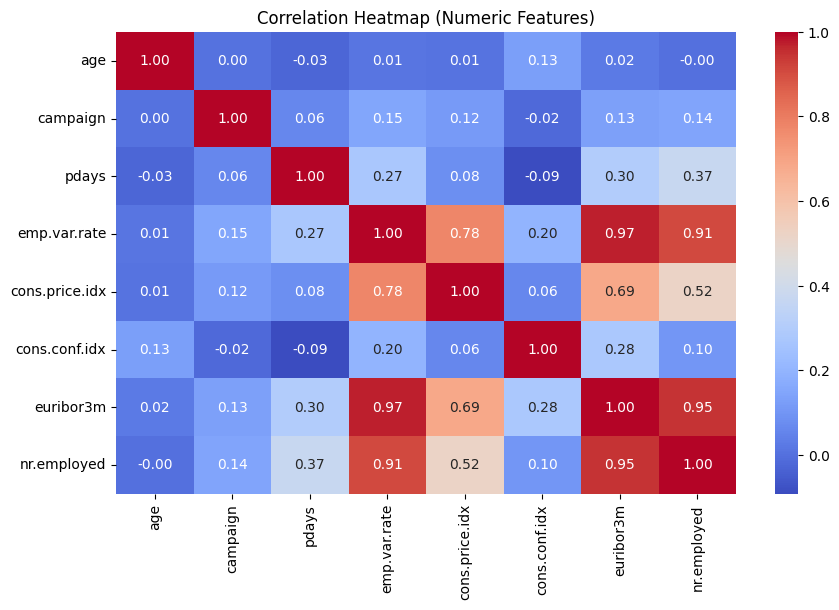

In [331]:
#Correlation (Numeric vs Numeric)
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

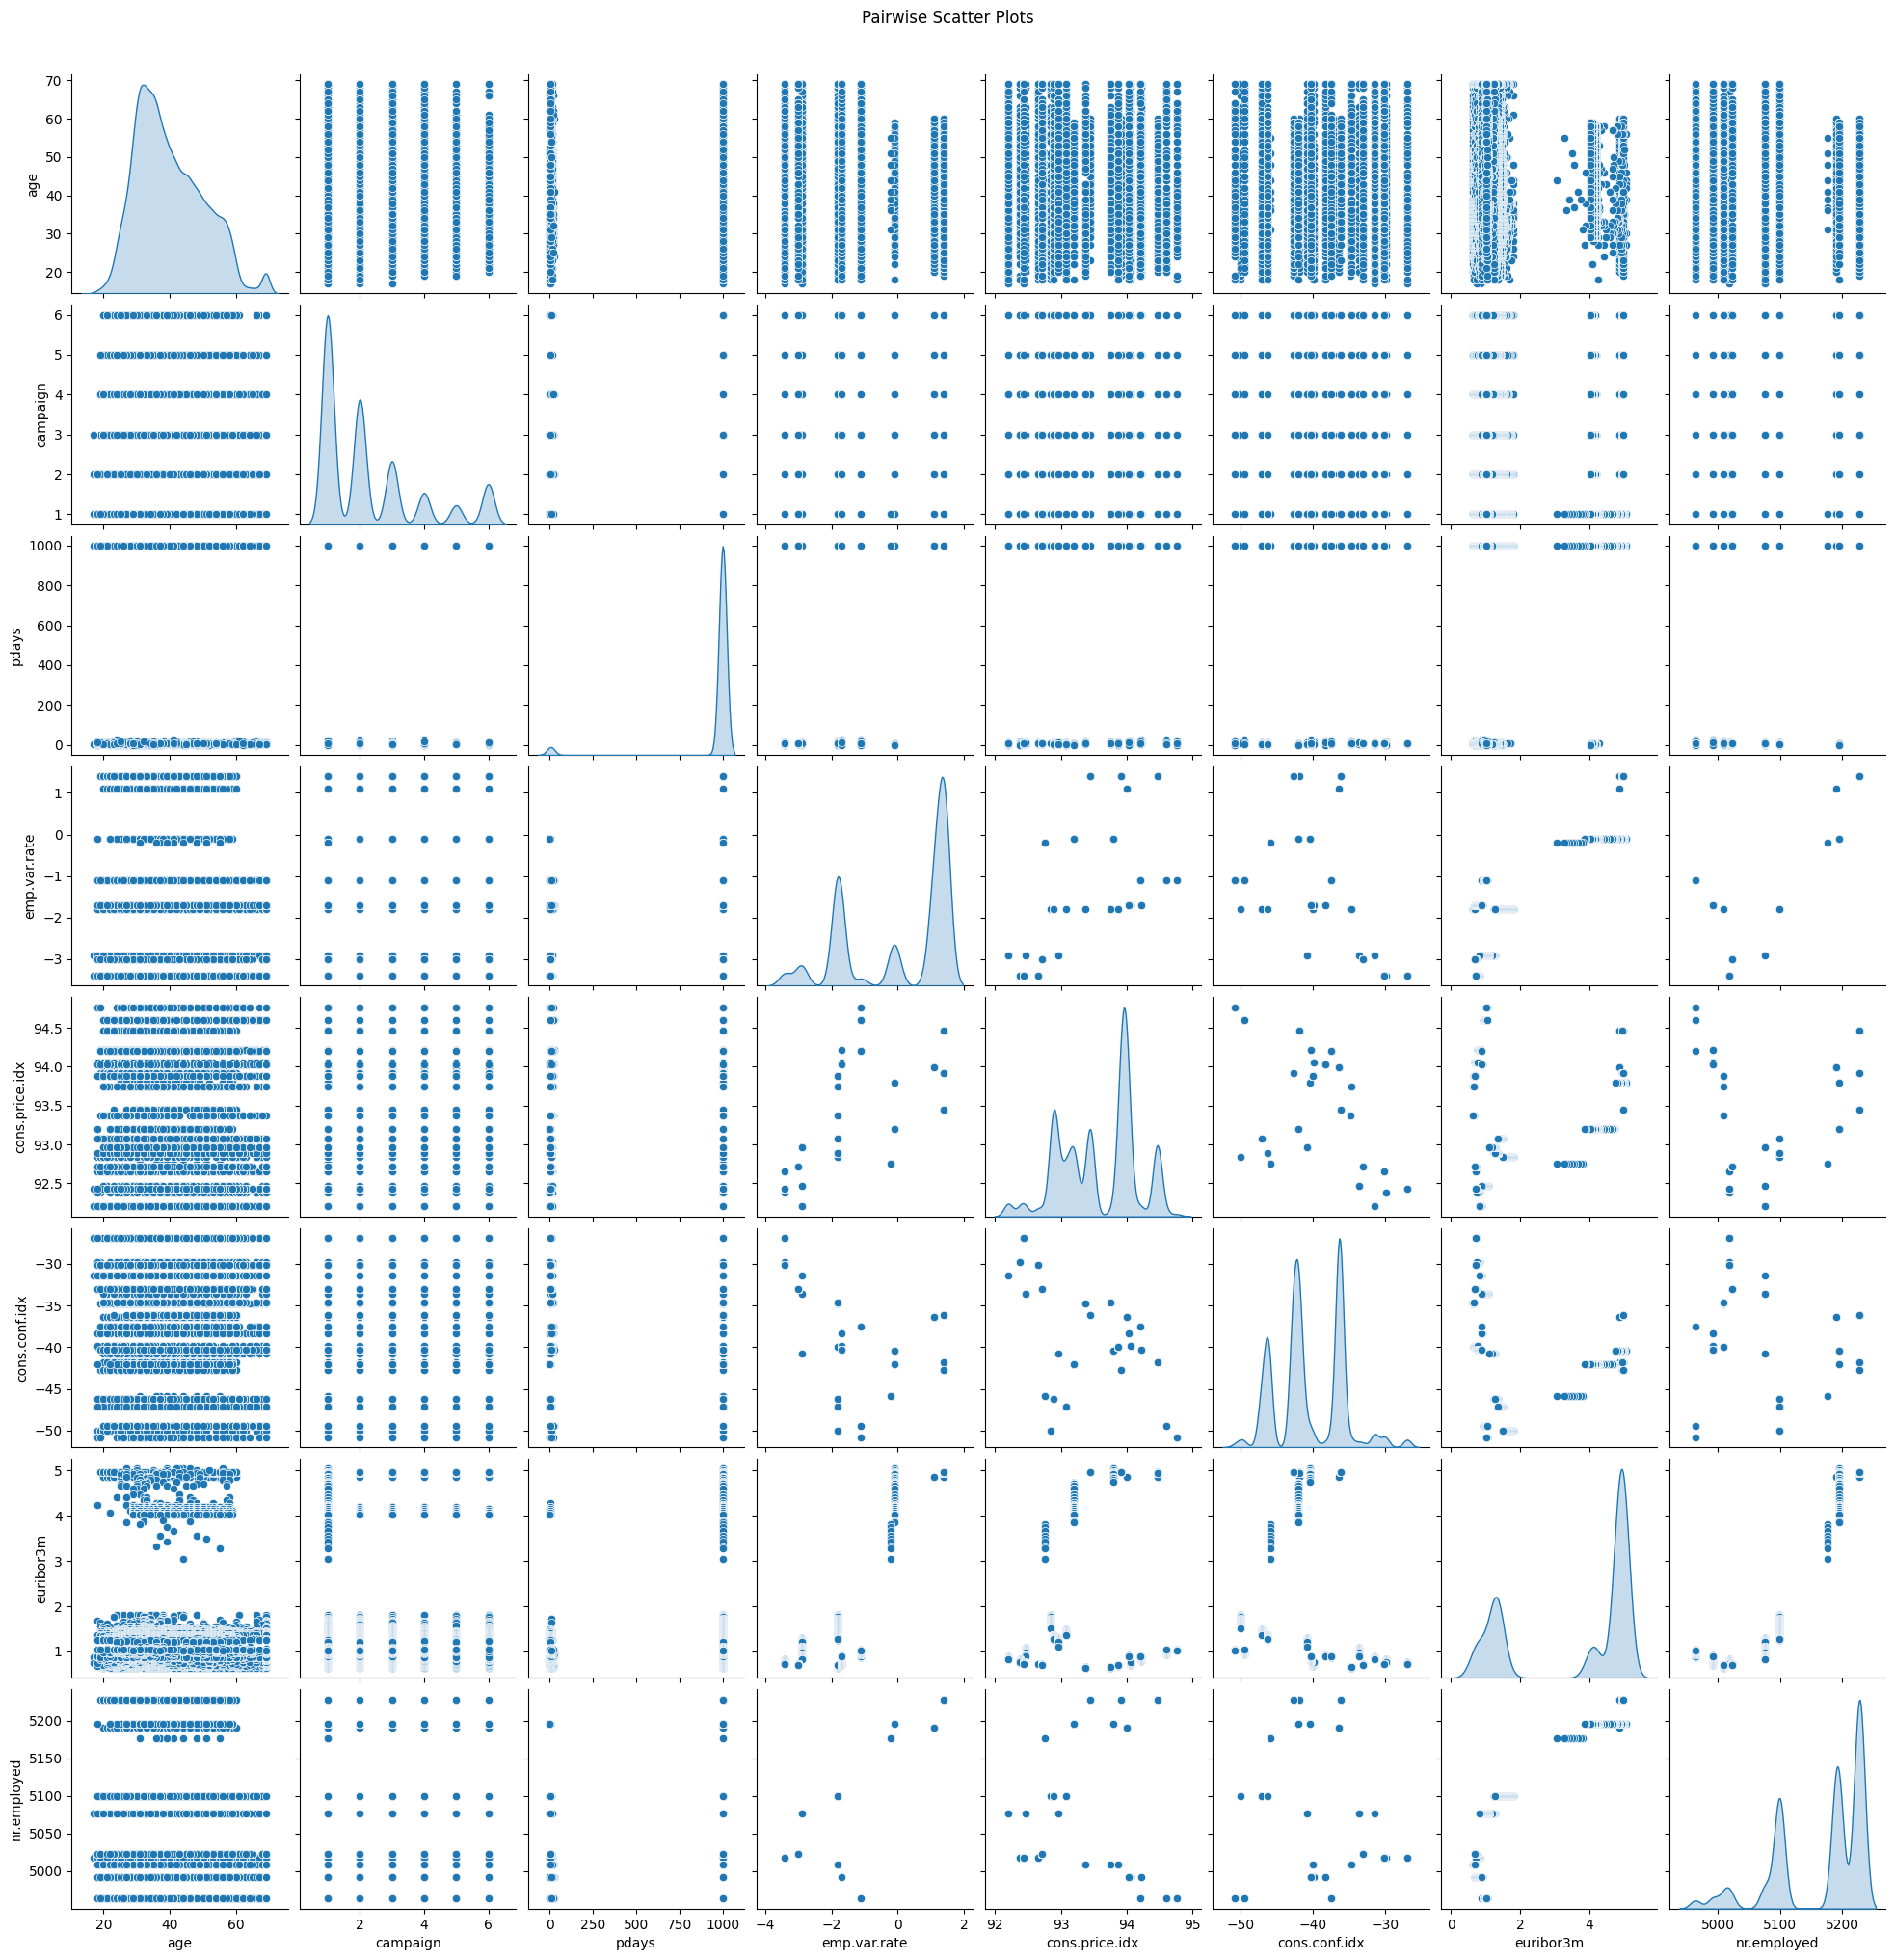

In [332]:
# Scatter plots between numeric pairs
sns.pairplot(df[num_cols], diag_kind="kde")
plt.suptitle("Pairwise Scatter Plots", y=1.02)
plt.show()

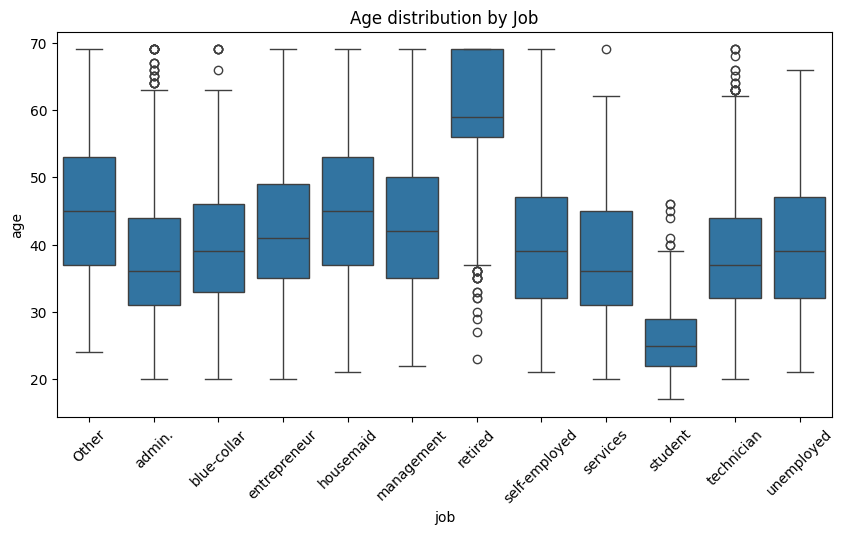

In [333]:
# Boxplots (Numeric vs Categorical) - Age distribution by job
plt.figure(figsize=(10,5))
sns.boxplot(x="job", y="age", data=df)
plt.xticks(rotation=45)
plt.title("Age distribution by Job")
plt.show()

## **3. Multivariate Analysis**

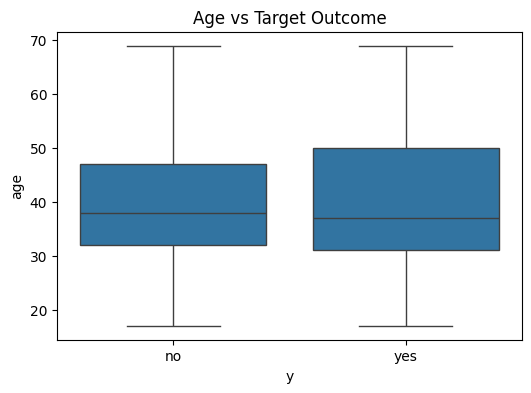

In [334]:
# Compare age across target outcome
plt.figure(figsize=(6,4))
sns.boxplot(x="y", y="age", data=df)
plt.title("Age vs Target Outcome")
plt.show()


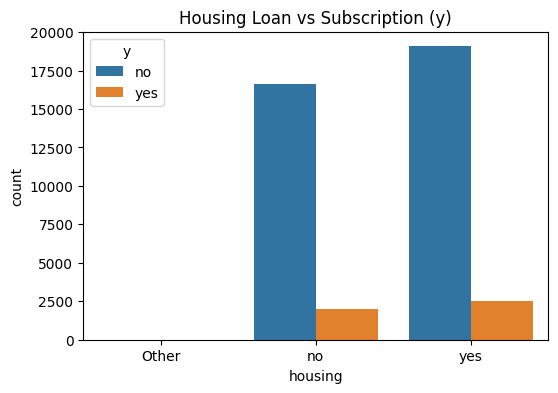

In [335]:
# Compare housing + loan vs target outcome
plt.figure(figsize=(6,4))
sns.countplot(x="housing", hue="y", data=df)
plt.title("Housing Loan vs Subscription (y)")
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40198 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             40198 non-null  int64   
 1   job             40198 non-null  category
 2   marital         40198 non-null  object  
 3   education       40198 non-null  category
 4   housing         40198 non-null  category
 5   loan            40198 non-null  category
 6   contact         40198 non-null  object  
 7   month           40198 non-null  object  
 8   day_of_week     40198 non-null  object  
 9   campaign        40198 non-null  int64   
 10  pdays           40198 non-null  int64   
 11  poutcome        40198 non-null  object  
 12  emp.var.rate    40198 non-null  float64 
 13  cons.price.idx  40198 non-null  float64 
 14  cons.conf.idx   40198 non-null  float64 
 15  euribor3m       40198 non-null  float64 
 16  nr.employed     40198 non-null  float64 
 17  y               4

### **Business objective** of this assignment is to build a predictive model that helps the bank identify which clients are most likely to subscribe to a term deposit after being contacted during a marketing campaign

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [337]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer, QuantileTransformer, OneHotEncoder, LabelEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

In [338]:
# 1. Separate features and target

X = df.drop("y", axis=1)   # features
y = df["y"]                # target

# Encode target variable (Label Encoding: no=0, yes=1)
y = LabelEncoder().fit_transform(y)

In [339]:
# Encode target variable (Label Encoding: no=0, yes=1)
y = LabelEncoder().fit_transform(y)

In [340]:
# 2. Identify column types

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['marital', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'campaign', 'pdays', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [341]:
# 3) Train/Test split (fit transforms ONLY on train)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state= 42, stratify=y
)
print("\nSplit shapes (train/test):", X_train.shape, X_test.shape)
print("Train target balance:", pd.Series(y_train).value_counts(normalize=True).round(3).to_dict())


Split shapes (train/test): (30148, 17) (10050, 17)
Train target balance: {0: 0.887, 1: 0.113}


In [342]:
X_train.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
4592,46,housemaid,married,basic.9y,no,no,telephone,may,tue,2,999,nonexistent,1.1,93.994,-36.4,4.856,5191.0
14680,50,admin.,married,university.degree,yes,no,cellular,jul,tue,3,999,nonexistent,1.4,93.918,-42.7,4.961,5228.1
8591,57,blue-collar,married,basic.9y,yes,yes,telephone,jun,wed,2,999,nonexistent,1.4,94.465,-41.8,4.864,5228.1
23382,37,technician,single,university.degree,yes,no,cellular,aug,wed,3,999,nonexistent,1.4,93.444,-36.1,4.964,5228.1
33261,31,blue-collar,married,basic.9y,yes,yes,cellular,may,tue,3,999,nonexistent,-1.8,92.893,-46.2,1.291,5099.1


In [343]:
# 4. ENCODING (OHE) + SCALING (Standard vs MinMax)

ohe = OneHotEncoder(handle_unknown="ignore")

# StandardScaler
preprocessor_standard = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", StandardScaler(), num_cols),])

# MinMaxScaler
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", MinMaxScaler(), num_cols),])

# Build a simple preprocessing pipelines
pipeline_standard = Pipeline(steps=[("preprocessor", preprocessor_standard)])
pipeline_minmax   = Pipeline(steps=[("preprocessor", preprocessor_minmax)])

#5) Fit on TRAIN only, then transform TRAIN and TEST
# =========================
X_train_std = pipeline_standard.fit_transform(X_train)
X_test_std  = pipeline_standard.transform(X_test)

X_train_mm  = pipeline_minmax.fit_transform(X_train)
X_test_mm   = pipeline_minmax.transform(X_test)

print("\n[After ENCODE + SCALE]")
print("StandardScaler shapes:", X_train_std.shape, X_test_std.shape)
print("MinMaxScaler shapes  :", X_train_mm.shape,  X_test_mm.shape)




[After ENCODE + SCALE]
StandardScaler shapes: (30148, 31) (10050, 31)
MinMaxScaler shapes  : (30148, 31) (10050, 31)


In [344]:
# 4. Build pipeline (preprocessing only)
pipeline_standard = Pipeline(steps=[("preprocessor", preprocessor_standard)])
pipeline_minmax   = Pipeline(steps=[("preprocessor", preprocessor_minmax)])

# 5. Apply transformations
X_standard = pipeline_standard.fit_transform(X)
X_minmax   = pipeline_minmax.fit_transform(X)
X_processed = pipeline_standard.fit_transform(X)

print("Shape before preprocessing:", X.shape)
print("Shape after preprocessing :", X_processed.shape)

Shape before preprocessing: (40198, 17)
Shape after preprocessing : (40198, 31)


In [345]:
#Double-check the exact categories used by OHE:

ohe = preprocessor_standard.named_transformers_['cat']
for col, cats in zip(cat_cols, ohe.categories_):
    print(f"{col}: {list(cats)}")

marital: ['divorced', 'married', 'single']
contact: ['cellular', 'telephone']
month: ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
day_of_week: ['fri', 'mon', 'thu', 'tue', 'wed']
poutcome: ['failure', 'nonexistent', 'success']


In [346]:
# quick checks:

print("First 5 StandardScaler values:\n", X_train_std[:5, :5].toarray() if hasattr(X_train_std, "toarray") else X_train_std[:5, :5])
print("\nFirst 5 MinMaxScaler values:\n", X_train_mm[:5, :5].toarray() if hasattr(X_train_mm, "toarray") else X_train_mm[:5, :5])

First 5 StandardScaler values:
 [[0. 1. 0. 0. 1.]
 [0. 1. 0. 1. 0.]
 [0. 1. 0. 0. 1.]
 [0. 0. 1. 1. 0.]
 [0. 1. 0. 1. 0.]]

First 5 MinMaxScaler values:
 [[0. 1. 0. 0. 1.]
 [0. 1. 0. 1. 0.]
 [0. 1. 0. 0. 1.]
 [0. 0. 1. 1. 0.]
 [0. 1. 0. 1. 0.]]


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [347]:
# Using StandardScaler for Logistic Regression

pd.Series(y_train).value_counts(normalize=True)[0].round(3)

# 0.887 is the baseline performance.

np.float64(0.887)

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [348]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import time

In [349]:
# 1. Baseline model (Dummy Classifier - always predicts the majority class)
dc = DummyClassifier(strategy="most_frequent", random_state=42)
dc.fit(X_train, y_train)
baseline_acc = dc.score(X_test, y_test)
print("Baseline (Most Frequent) Accuracy:", round(baseline_acc, 3))

Baseline (Most Frequent) Accuracy: 0.887


In [350]:
# Basic Logistic Regression model

lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_standard),   # your preprocessing transformer
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))  # the model
])

In [351]:
# Fit (train) the model on the training set
start = time.time()                 # record start time
lr_pipe.fit(X_train, y_train)       # fit pipeline on training data
train_time = time.time() - start    # calculate training time

# Evaluate/Score (test) model performance the model on the test set
train_acc = lr_pipe.score(X_train, y_train)
test_acc = lr_pipe.score(X_test, y_test)

# 4. Print results in a clean way
print("\n=== Logistic Regression Results ===")
print("Training Accuracy :", round(train_acc, 3))
print("Test Accuracy     :", round(test_acc, 3))
print("Training Time     :", round(train_time, 3), "seconds")


=== Logistic Regression Results ===
Training Accuracy : 0.901
Test Accuracy     : 0.9
Training Time     : 0.613 seconds


### Problem 9: Score the Model

What is the accuracy of your model?

90%

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [352]:
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [377]:
# Define models with default parameters
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC()
}

results = []

# Looping over models
for name, model in models.items():
    # Preprocessing: distance-based models (KNN, SVM) work better with MinMaxScaler
    if name in ["KNN", "SVM"]:
        preprocessor = preprocessor_minmax
    else:
        preprocessor = preprocessor_standard

    # Build pipeline
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])

    # Train and time it
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    # Scores
    train_acc = pipe.score(X_train, y_train)
    test_acc  = pipe.score(X_test, y_test)

    results.append([name, round(train_time,3), round(train_acc,3), round(test_acc,3)])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Train Time (s)", "Train Accuracy", "Test Accuracy"])
print(results_df)

                 Model  Train Time (s)  Train Accuracy  Test Accuracy
0  Logistic Regression           0.846           0.901          0.900
1                  KNN           0.153           0.912          0.892
2        Decision Tree           0.212           0.968          0.864
3                  SVM          53.280           0.904          0.900


In [378]:
# Since model is already trained (e.g., pipe.fit(X_train, y_train))
# Applying the preprocessor used for training the model to X_test
X_test_processed = preprocessor_minmax.transform(X_test)

y_pred = model.predict(X_test_processed)

# Compute metrics
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-score :", round(f1, 3))

Precision: 0.652
Recall   : 0.24
F1-score : 0.351


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

# **More feature engineering and exploration**
Should we keep the gender feature? Why or why not?
 - Gender often not directly relevant for predicting term deposits
 - Instead of raw age, create categories (<30, 30–50, 50+)


# **Hyperparameter tuning and Grid search**

In [364]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import time

In [365]:
def model_train_cv_score(model, model_name, params, X_train, y_train, X_test, y_test):
    grid_scv = GridSearchCV(model, params, scoring='accuracy', verbose=1)
    grid_scv.fit(X_train, y_train)
    train_time = grid_scv.cv_results_['mean_fit_time'].mean()

    acc_train = grid_scv.best_estimator_.score(X_train, y_train)
    acc_test = grid_scv.best_estimator_.score(X_test, y_test)

    record_results(model_name + ' grid_scv', train_time, acc_train, acc_test)

In [367]:
from sklearn.model_selection import GridSearchCV

model_name = 'KNN'
model = models[model_name]  # Directly access the model object
# Define parameters for the specific model
params = {'n_neighbors': [3, 5, 7, 9]} # Example parameters for KNN

grid_scv = GridSearchCV(model, params, scoring='accuracy', verbose=1)
grid_scv.fit(X_train_std, y_train) # Use the scaled data for KNN
#grid_scv.cv_results_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9]}, scoring='accuracy',
             verbose=1)

In [372]:
# Function to train model with GridSearchCV and return results
def model_train_cv_score(model, model_name, params, X_train, y_train, X_test, y_test):
    grid_scv = GridSearchCV(model, params, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
    grid_scv.fit(X_train, y_train)
    train_time = grid_scv.cv_results_['mean_fit_time'].mean()

    acc_train = grid_scv.best_estimator_.score(X_train, y_train)
    acc_test = grid_scv.best_estimator_.score(X_test, y_test)

    # return results row + grid object
    row = {
        "Model": model_name + " (GridSearchCV)",
        "Best Params": grid_scv.best_params_,
        "Train Time (s)": round(train_time, 3),
        "Train Accuracy": round(acc_train, 3),
        "Test Accuracy": round(acc_test, 3)
    }
    return row, grid_scv


models = {
    "KNN": (
        Pipeline([
            ("preprocessor", preprocessor_minmax),
            ("model", KNeighborsClassifier())
        ]),
        {"model__n_neighbors": [3, 5, 7, 11], "model__weights": ["uniform", "distance"]}
    ),
    "Decision Tree": (
        Pipeline([
            ("preprocessor", preprocessor_standard),
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        {"model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 5, 10]}
    )
}

# Run grid search for each model
results = []
for model_name, (estimator, param_grid) in models.items():
    row, grid = model_train_cv_score(estimator, model_name, param_grid, X_train, y_train, X_test, y_test)
    results.append(row)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
                          Model  \
0            KNN (GridSearchCV)   
1  Decision Tree (GridSearchCV)   

                                         Best Params  Train Time (s)  \
0  {'model__n_neighbors': 11, 'model__weights': '...           0.147   
1  {'model__max_depth': 5, 'model__min_samples_sp...           0.303   

   Train Accuracy  Test Accuracy  
0           0.904          0.897  
1           0.902          0.901  


# **Maximum depth of a Decision Tree**

In [374]:
# Decision Tree and grid for max_depth
dt = DecisionTreeClassifier(random_state=42)

# Trying different depths
param_grid = {"max_depth": list(range(1, 21))}  # depths 1 to 20

# GridSearchCV with cross-validation
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",     # can also try "f1" if imbalance matters
    cv=5,
    n_jobs=-1
)

# Fit on training data
# Applying the standard preprocessor to the training data before fitting
X_train_processed = preprocessor_standard.fit_transform(X_train)
grid.fit(X_train_processed, y_train)

# Best depth
print("Best max_depth:", grid.best_params_["max_depth"])
print("Best CV Accuracy:", round(grid.best_score_, 3))

# Evaluating on test data
best_dt = grid.best_estimator_
# Applying the standard preprocessor to the test data before scoring
X_test_processed = preprocessor_standard.transform(X_test)
print("Train Accuracy:", round(best_dt.score(X_train_processed, y_train), 3))
print("Test Accuracy :", round(best_dt.score(X_test_processed, y_test), 3))

Best max_depth: 5
Best CV Accuracy: 0.899
Train Accuracy: 0.902
Test Accuracy : 0.901


# **Adjust performance metric**

In [380]:
# 1) Split features/target
X = df.drop(columns=["y"]).copy()
y = df["y"].map({"no":0, "yes":1}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 2) Preprocessing blocks
num_pre = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pre = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

from sklearn.compose import make_column_selector as selector

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pre, selector(dtype_include=np.number)),
        ("cat", cat_pre, selector(dtype_exclude=np.number)),
    ]
)

# 3) Select top-K most informative features (mutual information)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
k = 30  # <<< choose how many features to keep
feature_selector = SelectKBest(score_func=mutual_info_classif, k=k)

# 4) Build a pipeline: preprocess -> select best features
fs_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("select", feature_selector)
])

# 5) Fit on TRAIN, transform TRAIN/TEST
X_train_reduced = fs_pipeline.fit_transform(X_train, y_train)
X_test_reduced  = fs_pipeline.transform(X_test)

print("Original shape :", X_train.shape)
print("Reduced shape  :", X_train_reduced.shape)

Original shape : (30148, 17)
Reduced shape  : (30148, 30)


In [384]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

# === 2) Loop through models ===
for name, model in models.items():
    # Preprocessing: distance-based models (KNN, SVM) work better with MinMaxScaler
    # However, I am using the fs_pipeline which already includes a scaler
    # Using the standard preprocessor within the fs_pipeline for consistency
    preprocessor_step = fs_pipeline.named_steps['preprocessor']

    # Pipeline: preprocessing + model
    # Since fs_pipeline already handles preprocessing and feature selection,
    # need to add the model to a new pipeline
    model_pipeline = Pipeline(steps=[
        ("model", model)
    ])

    # Applying the full feature selection pipeline to get the reduced data
    X_train_processed_reduced = fs_pipeline.transform(X_train)
    X_test_processed_reduced  = fs_pipeline.transform(X_test)

    # Fit + time
    start = time.time()
    model_pipeline.fit(X_train_processed_reduced, y_train)
    train_time = time.time() - start

    # Scores
    train_acc = model_pipeline.score(X_train_processed_reduced, y_train)
    test_acc  = model_pipeline.score(X_test_processed_reduced, y_test)

    results.append([name, round(train_time,3), round(train_acc,3), round(test_acc,3)])

# === 3) Convert to DataFrame ===
results_df = pd.DataFrame(results,
                          columns=["Model", "Train Time (s)", "Train Accuracy", "Test Accuracy"])

print(results_df)

                 Model  Train Time (s)  Train Accuracy  Test Accuracy
0  Logistic Regression           0.561           0.900          0.899
1                  KNN           0.006           0.912          0.894
2        Decision Tree           0.146           0.980          0.853
3                  SVM         453.193           0.903          0.901


##### Questions